<a href="https://colab.research.google.com/github/socode6/Advanced_Python-DataScience/blob/main/modified_datapipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pipeline Overview:

1.Load raw data
2.Handle the Target correctly (binary: Dropout vs Graduate)
3.Separate Enrolled students (inference set) from training data
4.One-Hot Encode categorical columns properly
5.Scale continuous columns
6.Train/Test split
7.Apply SMOTE only on training data
8.Save everything cleanly for modeling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print('All imports successful')

All imports successful


In [ ]:
df = pd.read_csv('dataset.csv')

print(f'Shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['Target'].value_counts())
print(f'\nNull values: {df.isnull().sum().sum()}')

df.head()

Shape: (4424, 35)

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Null values: 0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# These are already 0/1 — leave them as-is
binary_cols = [
    'Daytime/evening attendance',
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International',
]

# These are integer codes with NO natural order — must be One-Hot Encoded
# (e.g. Course 3 is not "more" than Course 1, they're just different courses)
nominal_cols = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
]

# True numerical values — apply StandardScaler
continuous_cols = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
]

print(f'Binary cols: {len(binary_cols)}')
print(f'Nominal cols to OHE: {len(nominal_cols)}')
print(f'Continuous cols to scale: {len(continuous_cols)}')

all_feature_cols = binary_cols + nominal_cols + continuous_cols
original_feature_cols = [c for c in df.columns if c != 'Target']
missed = set(original_feature_cols) - set(all_feature_cols)
print(f'\nMissed columns (should be empty): {missed}')

Binary cols: 8
Nominal cols to OHE: 10
Continuous cols to scale: 16

Missed columns (should be empty): set()


In [ ]:
# Separate the enrolled students out before any further processing
df_enrolled = df[df['Target'] == 'Enrolled'].copy()
df_model = df[df['Target'] != 'Enrolled'].copy()

print(f'Total rows: {len(df)}')
print(f'Enrolled (inference set, set aside): {len(df_enrolled)}')
print(f'Known outcome rows (for training): {len(df_model)}')
print(f'\nClass distribution in training pool:')
print(df_model['Target'].value_counts())

Total rows: 4424
Enrolled (inference set, set aside): 794
Known outcome rows (for training): 3630

Class distribution in training pool:
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64


In [ ]:
df_model['target_binary'] = (df_model['Target'] == 'Dropout').astype(int)

print('Target encoding:')
print(df_model.groupby('Target')['target_binary'].first())
print(f'\nClass balance:')
print(df_model['target_binary'].value_counts())
print(f'\nDropout rate: {df_model["target_binary"].mean():.1%}')

# Drop the original Target string column
df_model = df_model.drop(columns=['Target'])

Target encoding:
Target
Dropout     1
Graduate    0
Name: target_binary, dtype: int64

Class balance:
target_binary
0    2209
1    1421
Name: count, dtype: int64

Dropout rate: 39.1%


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Prepare enrolled features (drop Target string column)
df_enrolled_processed = df_enrolled.drop(columns=['Target'])

# Initialise encoder
# drop='first'         → avoids dummy variable trap (multicollinearity)
# sparse_output=False  → returns a regular numpy array, not a sparse matrix
# handle_unknown='ignore' → if enrolled students have unseen categories, they become all-zeros
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# STEP A: fit + transform on training data only
# The encoder LEARNS all valid categories from df_model here
ohe_train_array = ohe.fit_transform(df_model[nominal_cols])

# STEP B: transform enrolled data using the SAME learned categories
# Never fit again — just apply the same rules
ohe_enrolled_array = ohe.transform(df_enrolled_processed[nominal_cols])

# Get the generated column names
ohe_feature_names = ohe.get_feature_names_out(nominal_cols)

# Convert arrays back to DataFrames with proper column names
ohe_train_df = pd.DataFrame(ohe_train_array, columns=ohe_feature_names, index=df_model.index)
ohe_enrolled_df = pd.DataFrame(ohe_enrolled_array, columns=ohe_feature_names, index=df_enrolled_processed.index)

# Drop original nominal columns and attach the new OHE columns
df_encoded = pd.concat(
    [df_model.drop(columns=nominal_cols).reset_index(drop=True),
     ohe_train_df.reset_index(drop=True)],
    axis=1
)
df_enrolled_encoded = pd.concat(
    [df_enrolled_processed.drop(columns=nominal_cols).reset_index(drop=True),
     ohe_enrolled_df.reset_index(drop=True)],
    axis=1
)

print(f'Shape before OHE: {df_model.shape}')
print(f'Shape after OHE:  {df_encoded.shape}')
print(f'New columns added: {df_encoded.shape[1] - df_model.shape[1]}')
print(f'\nColumn count match between train and enrolled: {df_encoded.shape[1] == df_enrolled_encoded.shape[1] + 1}')  # +1 because train has target_binary
print(f'Learned categories per column (sample):')
for col, cats in zip(nominal_cols[:], ohe.categories_[:]):
    print(f'  {col}: {len(cats)} categories')

Shape before OHE: (3630, 35)
Shape after OHE:  (3630, 233)
New columns added: 198

Column count match between train and enrolled: True
Learned categories per column (sample):
  Marital status: 6 categories
  Application mode: 18 categories
  Application order: 7 categories
  Course: 17 categories
  Previous qualification: 17 categories
  Nacionality: 19 categories
  Mother's qualification: 29 categories
  Father's qualification: 34 categories
  Mother's occupation: 29 categories
  Father's occupation: 42 categories


In [ ]:
# Separate features and target
X = df_encoded.drop(columns=['target_binary'])
y = df_encoded['target_binary']

# stratify=y ensures both train and test sets have similar class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Important for imbalanced classes
)

print(f'Training set:   {X_train.shape}')
print(f'Test set:       {X_test.shape}')
print(f'\nClass balance in training set:')
print(y_train.value_counts())
print(f'\nClass balance in test set:')
print(y_test.value_counts())

Training set:   (2904, 232)
Test set:       (726, 232)

Class balance in training set:
target_binary
0    1767
1    1137
Name: count, dtype: int64

Class balance in test set:
target_binary
0    442
1    284
Name: count, dtype: int64


In [ ]:
cols_to_scale = [c for c in continuous_cols if c in X_train.columns]
scaler = StandardScaler()

# Fit ONLY on training data, then transform
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Only transform test data — never fit on it
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f'Scaled {len(cols_to_scale)} continuous columns')
print(f'\nSample of scaled values (should be roughly -3 to +3):')
X_train[cols_to_scale[:3]].describe().round(3)

Scaled 16 continuous columns

Sample of scaled values (should be roughly -3 to +3):


,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled)
count,2904.000,2904.000,2904.000
mean,-0.000,0.000,0.000
std,1.000,1.000,1.000
min,-0.825,-0.304,-2.474
25%,-0.571,-0.304,-0.524
50%,-0.443,-0.304,-0.134
75%,0.322,-0.304,0.256
max,4.910,7.796,7.665


In [ ]:
print('Before SMOTE:')
print(f'  Graduates (0): {(y_train == 0).sum()}')
print(f'  Dropouts  (1): {(y_train == 1).sum()}')

Before SMOTE:
  Graduates (0): 1767
  Dropouts  (1): 1137


In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE:')
print(f'  Graduates (0): {(y_train_resampled == 0).sum()}')
print(f'  Dropouts  (1): {(y_train_resampled == 1).sum()}')
print(f'\nX_test is untouched: {X_test.shape} rows — GOOD')


After SMOTE:
  Graduates (0): 1767
  Dropouts  (1): 1767

X_test is untouched: (726, 232) rows — GOOD


In [ ]:
X_enrolled = df_enrolled_encoded.copy()
# Scale continuous columns using the SAME scaler fitted on training data
enrolled_cols_to_scale = [c for c in cols_to_scale if c in X_enrolled.columns]
X_enrolled[enrolled_cols_to_scale] = scaler.transform(X_enrolled[enrolled_cols_to_scale])

print(f'Enrolled inference set shape: {X_enrolled.shape}')
print(f'Training features shape:      {X_train_resampled.shape}')
print(f'\nColumn match: {list(X_enrolled.columns) == list(X_train.columns)}')

Enrolled inference set shape: (794, 232)
Training features shape:      (3534, 232)

Column match: True


In [ ]:
print('=' * 50)
print('PREPROCESSING COMPLETE — FINAL SUMMARY')
print('=' * 50)
print(f'\nTraining set (after SMOTE): {X_train_resampled.shape}')
print(f'Test set (real data only):  {X_test.shape}')
print(f'Enrolled inference set:     {X_enrolled.shape}')
print(f'\nFeature count: {X_train_resampled.shape[1]}')
print(f'\nTraining class balance:')
vals, counts = np.unique(y_train_resampled, return_counts=True)
for v, c in zip(vals, counts):
    label = 'Dropout' if v == 1 else 'Graduate'
    print(f'  {label} ({v}): {c}')

print(f'\nNull check — train: {np.isnan(X_train_resampled).sum()}')
print(f'Null check — test:  {X_test.isnull().sum().sum()}')
print('\nReady for modeling!')

PREPROCESSING COMPLETE — FINAL SUMMARY

Training set (after SMOTE): (3534, 232)
Test set (real data only):  (726, 232)
Enrolled inference set:     (794, 232)

Feature count: 232

Training class balance:
  Graduate (0): 1767
  Dropout (1): 1767

Null check — train: Daytime/evening attendance    0
Displaced                     0
Educational special needs     0
Debtor                        0
Tuition fees up to date       0
                             ..
Father's occupation_42        0
Father's occupation_43        0
Father's occupation_44        0
Father's occupation_45        0
Father's occupation_46        0
Length: 232, dtype: int64
Null check — test:  0

Ready for modeling!


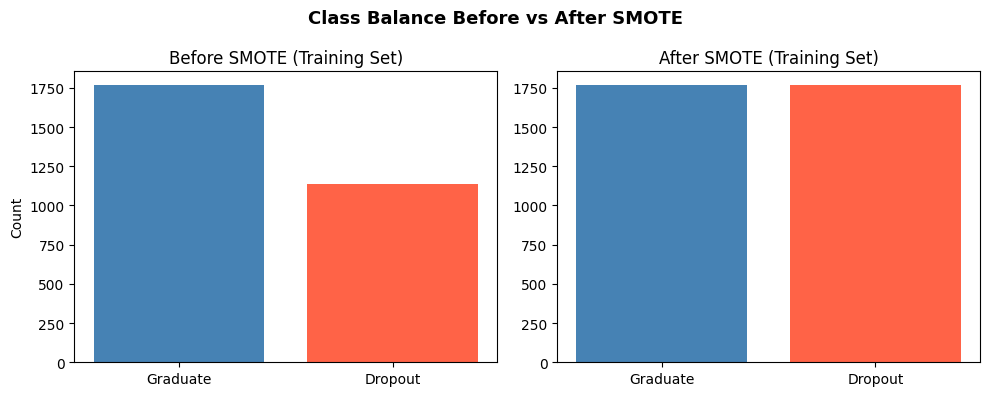

In [ ]:
# Visualise class balance before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Graduate', 'Dropout'], [( y_train == 0).sum(), (y_train == 1).sum()],
            color=['steelblue', 'tomato'])
axes[0].set_title('Before SMOTE (Training Set)')
axes[0].set_ylabel('Count')

axes[1].bar(['Graduate', 'Dropout'],
            [(y_train_resampled == 0).sum(), (y_train_resampled == 1).sum()],
            color=['steelblue', 'tomato'])
axes[1].set_title('After SMOTE (Training Set)')

plt.suptitle('Class Balance Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Save datasets as CSV
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns)
X_train_resampled_df['target'] = y_train_resampled
X_train_resampled_df.to_csv('train_data.csv', index=False)

X_test_df = X_test.copy()
X_test_df['target'] = y_test.values
X_test_df.to_csv('test_data.csv', index=False)

X_enrolled.to_csv('enrolled_inference.csv', index=False)
# Save the scaler so you can use it consistently in modeling
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Saved:')
print('  train_data.csv        — SMOTE-balanced training data')
print('  test_data.csv         — Real test data (never touch this for training)')
print('  enrolled_inference.csv — Students to predict dropout risk for')
print('  scaler.pkl            — Fitted scaler (reuse in modeling notebook)')

Saved:
  train_data.csv        — SMOTE-balanced training data
  test_data.csv         — Real test data (never touch this for training)
  enrolled_inference.csv — Students to predict dropout risk for
  scaler.pkl            — Fitted scaler (reuse in modeling notebook)
